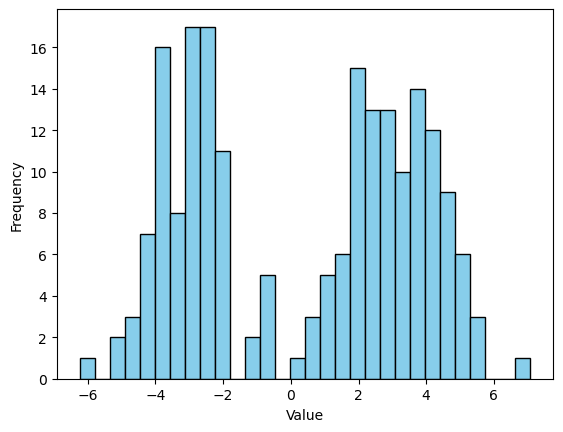

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulate data ---
np.random.seed(42)
n = 200
true_mu = [-3, 3]
true_sigma = [1.0, 1.5]
true_pi = [0.4, 0.6]
z_true = np.random.choice([0, 1], size=n, p=true_pi)
x_data = np.array([np.random.normal(true_mu[z], true_sigma[z]) for z in z_true])


# Create the histogram, which will allow us to see that there are 2 modes in the data and hence a Gaussian mixture is a good model
# We need this step because in a real world setting we will not simulate our own data but rather we would be given a set of x_i and
# just have to infer the model parameters
plt.hist(x_data, bins=30, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the histogram
plt.show()

In [2]:
import pymc as pm

with pm.Model() as model:
    pi = pm.Dirichlet("pi", a=[1., 1.])
    mu = pm.Normal("mu", mu=0, sigma=10, shape=2)
    sigma = pm.InverseGamma("sigma2", alpha=2, beta=2, shape=2)

    x_obs = pm.Mixture(
        "x_obs",
        w=pi,
        comp_dists=pm.Normal.dist(mu=mu, sigma=pm.math.sqrt(sigma), shape=2),
        observed=x_data
    )

    trace = pm.sample(1000, tune=1000, chains=2, return_inferencedata=True, target_accept=0.9)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [pi, mu, sigma2]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 6 seconds.


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu[0]      0.039  3.053  -3.184    3.288      2.149    1.817       3.0   
mu[1]      0.039  3.055  -3.192    3.289      2.150    1.818       3.0   
pi[0]      0.500  0.067   0.391    0.615      0.041    0.033       3.0   
pi[1]      0.500  0.067   0.385    0.609      0.041    0.033       3.0   
sigma2[0]  1.412  0.398   0.784    2.084      0.243    0.195       3.0   
sigma2[1]  1.411  0.408   0.768    2.093      0.248    0.198       3.0   

           ess_tail  r_hat  
mu[0]          73.0   1.83  
mu[1]          75.0   1.83  
pi[0]          64.0   1.76  
pi[1]          64.0   1.76  
sigma2[0]     114.0   1.77  
sigma2[1]      72.0   1.75  


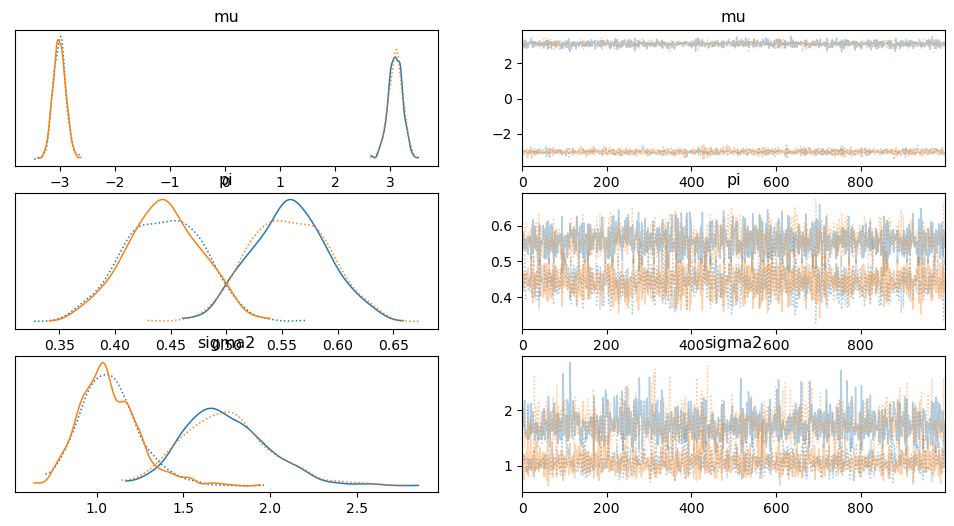

In [3]:
import arviz as az
# Summary of posterior
print(az.summary(trace))

# Traceplot
az.plot_trace(trace)
plt.show()